# Airport Network Analysis — Communities and Resilience

This notebook examines regional communities and estimates how sensitive the network is to the removal of major hubs.

## Objective

The objective of this notebook is to evaluate the resilience of the global airport network under different disruption scenarios.

Specifically, this notebook investigates:

- Community structure within the airport network.
- The effect of random airport failures.
- The impact of targeted removal of highly connected hub airports.
- The impact of removing airports with high betweenness centrality.
- Comparison of different attack strategies to identify the network's vulnerabilities.

In [50]:
import sys
from pathlib import Path
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

sys.path.append(str(Path('../src').resolve()))
from graph_builder import build_graph

G = build_graph('../Data')
undirected_G = G.to_undirected()

In [51]:
baseline_size = len(
    max(
        nx.connected_components(undirected_G),
        key=len
    )
)

print("Baseline largest component:", baseline_size)

Baseline largest component: 3188


In [52]:
airports = pd.read_csv("../Data/airports.dat", header=None)
routes = pd.read_csv("../Data/routes.dat", header=None)

In [53]:
airports.columns = [
    "Airport_ID",
    "Airport_Name",
    "City",
    "Country",
    "IATA",
    "ICAO",
    "Latitude",
    "Longitude",
    "Altitude",
    "Timezone",
    "DST",
    "Timezone_Database",
    "Type",
    "Source"
]


In [54]:
airport_lookup = airports[
    ["Airport_ID", "Airport_Name", "City", "Country", "IATA"]
].copy()

airport_lookup["Airport_ID"] = pd.to_numeric(
    airport_lookup["Airport_ID"],
    errors="coerce"
)

In [55]:
print("Number of nodes:", undirected_G.number_of_nodes())
print("Number of edges:", undirected_G.number_of_edges())

Number of nodes: 3214
Number of edges: 18859


## 2. Community Detection

The Louvain algorithm groups airports that have more route connections within the same group than with other groups.

In [38]:
communities = nx.community.louvain_communities(undirected_G, seed=42)
community_rows = []
for community_id, members in enumerate(communities, start=1):
    countries = pd.Series([G.nodes[node]['country'] for node in members]).value_counts().head(3)
    community_rows.append({
        'community': community_id,
        'airports': len(members),
        'dominant_countries': ', '.join(f'{country} ({count})' for country, count in countries.items())
    })

community_summary = pd.DataFrame(community_rows).sort_values('airports', ascending=False)
community_summary.head(15).reset_index(drop=True)

,community,airports,dominant_countries
0,14,732,"United States (410), Canada (70), Mexico (56)"
1,5,510,"France (54), United Kingdom (45), Spain (40)"
2,4,463,"India (67), Iran (38), Turkey (35)"
3,11,405,"Australia (113), Indonesia (63), Philippines (35)"
4,12,322,"China (172), Japan (62), Vietnam (20)"
5,13,212,"Brazil (122), Argentina (36), Peru (19)"
6,22,161,"Russia (103), Kazakhstan (17), Uzbekistan (11)"
7,15,131,United States (131)
8,1,110,Canada (110)
9,9,27,French Polynesia (27)


## 3. Random Failure Analysis

To assess whether the global airport network is more vulnerable to targeted hub failures than to random failures, airports are removed randomly at different failure levels. The experiment is repeated across multiple random trials to account for variation in the selected airports.

In [39]:
import numpy as np
import random

random_levels = [0, 1, 5, 10, 20, 50]

random_results = []

for removed in random_levels:

    largest_components = []

    for _ in range(100):

        G_temp = undirected_G.copy()

        if removed > 0:
            removed_nodes = random.sample(
                list(G_temp.nodes()),
                removed
            )

            G_temp.remove_nodes_from(removed_nodes)

        if G_temp.number_of_nodes() > 0:

            largest = len(
                max(
                    nx.connected_components(G_temp),
                    key=len
                )
            )

        else:
            largest = 0

        largest_components.append(largest)

    random_results.append({

        "airports_removed": removed,

        "largest_component_mean":
            np.mean(largest_components),

        "largest_component_std":
            np.std(largest_components),

        "share_of_original_largest_component":
            np.mean(largest_components)/baseline_size

    })

random_resilience = pd.DataFrame(random_results)

random_resilience

,airports_removed,largest_component_mean,largest_component_std,share_of_original_largest_component
0,0,3188.00,0.000000,1.000000
1,1,3186.95,0.384057,0.999671
2,5,3181.14,3.990038,0.997848
3,10,3174.66,4.563376,0.995816
4,20,3161.68,7.018376,0.991744
5,50,3118.65,19.486085,0.978247


In [40]:
import random
random.seed(42)

removal_levels = [0, 1, 5, 10, 20, 50]
n_trials = 100

repeated_random_results = []

for removed_count in removal_levels:
    
    for trial in range(n_trials):
        
        # Randomly select airports to remove
        randomly_removed = random.sample(
            list(undirected_G.nodes()),
            removed_count
        )
        
        # Work on a copy of the original network
        remaining = undirected_G.copy()
        
        # Remove randomly selected airports
        remaining.remove_nodes_from(randomly_removed)
        
        # Find the largest connected component
        largest = (
            len(max(nx.connected_components(remaining), key=len))
            if remaining.number_of_nodes() > 0
            else 0
        )
        
        repeated_random_results.append({
            'airports_removed': removed_count,
            'trial': trial + 1,
            'largest_component': largest,
            'share_of_original_largest_component': largest / baseline_size
        })

repeated_random_resilience = pd.DataFrame(repeated_random_results)

repeated_random_resilience.head(10)

,airports_removed,trial,largest_component,share_of_original_largest_component
0,0,1,3188,1.0
1,0,2,3188,1.0
2,0,3,3188,1.0
3,0,4,3188,1.0
4,0,5,3188,1.0
5,0,6,3188,1.0
6,0,7,3188,1.0
7,0,8,3188,1.0
8,0,9,3188,1.0
9,0,10,3188,1.0


In [41]:
random_summary = (
    repeated_random_resilience
    .groupby('airports_removed')
    .agg(
        mean_largest_component=('largest_component', 'mean'),
        std_largest_component=('largest_component', 'std'),
        mean_share=('share_of_original_largest_component', 'mean'),
        min_share=('share_of_original_largest_component', 'min'),
        max_share=('share_of_original_largest_component', 'max')
    )
    .reset_index()
)

random_summary

,airports_removed,mean_largest_component,std_largest_component,mean_share,min_share,max_share
0,0,3188.00,0.000000,1.000000,1.000000,1.000000
1,1,3186.87,0.613896,0.999646,0.998118,1.000000
2,5,3181.38,3.404631,0.997923,0.992158,0.998745
3,10,3174.12,5.168436,0.995646,0.988708,0.997177
4,20,3160.48,12.235468,0.991368,0.960163,0.993726
5,50,3118.97,15.832746,0.978347,0.948871,0.983689


## 4. Degree Centrality Analysis

Degree centrality measures the importance of an airport based on the number of direct flight connections it has. Airports with higher degree centrality act as major hubs and play a crucial role in maintaining connectivity across the global airport network.

In [42]:
degree_centrality = nx.degree_centrality(undirected_G)

degree_ranking = (
    pd.DataFrame(
        degree_centrality.items(),
        columns=["airport_id", "degree_centrality"]
    )
    .sort_values("degree_centrality", ascending=False)
)

degree_ranking.head(20)

,airport_id,degree_centrality
282,580,0.077186
191,340,0.075941
628,1382,0.074697
770,1701,0.072518
1809,3682,0.067538
1885,3830,0.064115
1642,3364,0.063803
196,346,0.059757
2016,4029,0.058512
1800,3670,0.058512


In [43]:
top_hubs = degree_ranking.merge(
    airport_lookup,
    left_on="airport_id",
    right_on="Airport_ID",
    how="left"
)

top_hubs[
    [
        "airport_id",
        "IATA",
        "Airport_Name",
        "City",
        "Country",
        "degree_centrality"
    ]
].head(20)

,airport_id,IATA,Airport_Name,City,Country,degree_centrality
0,580,AMS,Amsterdam Airport Schiphol,Amsterdam,Netherlands,0.077186
1,340,FRA,Frankfurt am Main Airport,Frankfurt,Germany,0.075941
2,1382,CDG,Charles de Gaulle International Airport,Paris,France,0.074697
3,1701,ISL,Atatürk International Airport,Istanbul,Turkey,0.072518
4,3682,ATL,Hartsfield Jackson Atlanta International Airport,Atlanta,United States,0.067538
5,3830,ORD,Chicago O'Hare International Airport,Chicago,United States,0.064115
6,3364,PEK,Beijing Capital International Airport,Beijing,China,0.063803
7,346,MUC,Munich Airport,Munich,Germany,0.059757
8,4029,DME,Domodedovo International Airport,Moscow,Russia,0.058512
9,3670,DFW,Dallas Fort Worth International Airport,Dallas-Fort Worth,United States,0.058512


### Interpretation

The airports with the highest degree centrality are major international hubs such as Amsterdam Schiphol (AMS), Frankfurt (FRA), and Charles de Gaulle (CDG). These airports maintain the largest number of direct flight connections and therefore play a critical role in preserving global connectivity.

Since these airports connect many destinations, their removal is expected to have a much larger impact on the network than the removal of randomly selected airports.

## 5. Degree-Based Targeted Failure Analysis

In [44]:
targeted_removal_levels = [0, 1, 5, 10, 20, 50]

targeted_results = []

# Airports ranked from highest to lowest degree centrality
ranked_airports = degree_ranking["airport_id"].tolist()

for removed_count in targeted_removal_levels:

    # Select the top-ranked airports
    targeted_removed = ranked_airports[:removed_count]

    # Copy the original network
    remaining = undirected_G.copy()

    # Remove the selected hubs
    remaining.remove_nodes_from(targeted_removed)

    # Find largest connected component
    largest = (
        len(max(nx.connected_components(remaining), key=len))
        if remaining.number_of_nodes() > 0
        else 0
    )

    targeted_results.append({
        "airports_removed": removed_count,
        "largest_component": largest,
        "share_of_original_largest_component":
            largest / baseline_size
    })

targeted_resilience = pd.DataFrame(targeted_results)

targeted_resilience

,airports_removed,largest_component,share_of_original_largest_component
0,0,3188,1.000000
1,1,3187,0.999686
2,5,3167,0.993413
3,10,3129,0.981493
4,20,3080,0.966123
5,50,2955,0.926913


## 6. Random v/s Targeted Failure Comparison


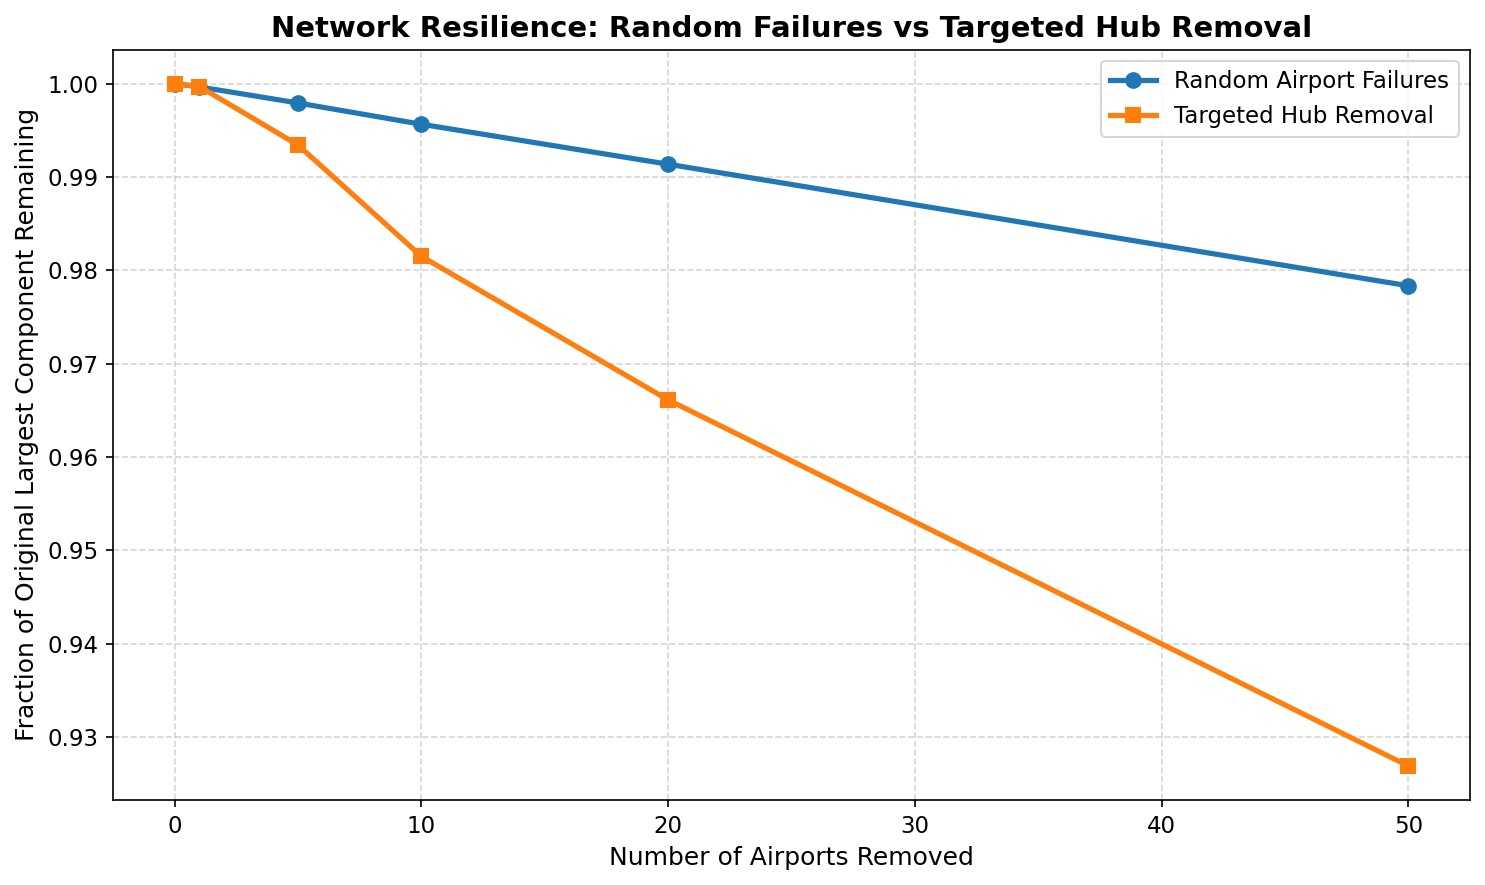

In [45]:
plt.figure(figsize=(10, 6), dpi=150)

plt.plot(
    random_summary["airports_removed"],
    random_summary["mean_share"],
    marker="o",
    markersize=7,
    linewidth=2.5,
    label="Random Airport Failures"
)

plt.plot(
    targeted_resilience["airports_removed"],
    targeted_resilience["share_of_original_largest_component"],
    marker="s",
    markersize=7,
    linewidth=2.5,
    label="Targeted Hub Removal"
)

plt.xlabel("Number of Airports Removed", fontsize=12)
plt.ylabel("Fraction of Original Largest Component Remaining", fontsize=12)

plt.title(
    "Network Resilience: Random Failures vs Targeted Hub Removal",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(True, linestyle="--", alpha=0.5)

plt.legend(fontsize=11)

plt.tight_layout()

plt.savefig(
    "../Reports/figures/_Random_vs_Targeted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

This figure compares the resilience of the global airport network under two different disruption scenarios: random airport failures and targeted removal of high-degree hub airports.

The random failure curve decreases gradually, indicating that the network remains largely connected even after several randomly selected airports are removed. This demonstrates the inherent robustness of the airport network against isolated or unpredictable disruptions.

In contrast, the targeted hub removal curve drops much more rapidly. Removing only a small number of highly connected hub airports significantly reduces the size of the largest connected component. This indicates that a relatively small set of major hub airports is responsible for maintaining global connectivity.

Overall, the results show that the airport network is resilient to random failures but highly vulnerable to deliberate attacks or failures involving critical hub airports.

In [49]:
comparison = random_summary[
    ["airports_removed", "mean_share"]
].merge(
    targeted_resilience[
        ["airports_removed", "share_of_original_largest_component"]
    ],
    on="airports_removed"
)

comparison["targeted_damage"] = (
    comparison["mean_share"]
    - comparison["share_of_original_largest_component"]
)

comparison["targeted_damage_percent"] = (
    comparison["targeted_damage"] * 100
)

comparison

,airports_removed,mean_share,share_of_original_largest_component,targeted_damage,targeted_damage_percent
0,0,1.000000,1.000000,0.000000,0.000000
1,1,0.999646,0.999686,-0.000041,-0.004078
2,5,0.997923,0.993413,0.004511,0.451066
3,10,0.995646,0.981493,0.014153,1.415307
4,20,0.991368,0.966123,0.025245,2.524467
5,50,0.978347,0.926913,0.051434,5.143350


## 7. Betweenness Centrality

In [28]:
betweenness_centrality = nx.betweenness_centrality(
    undirected_G,
    normalized=True
)

betweenness_ranking = (
    pd.DataFrame(
        betweenness_centrality.items(),
        columns=["airport_id", "betweenness_centrality"]
    )
    .sort_values(
        "betweenness_centrality",
        ascending=False
    )
)

betweenness_ranking.head(20)

,airport_id,betweenness_centrality
628,1382,0.063563
1715,3484,0.060503
1861,3774,0.058427
1017,2188,0.055406
191,340,0.052432
282,580,0.051063
1642,3364,0.049788
1885,3830,0.046583
125,193,0.044345
770,1701,0.042428


In [29]:
top_betweenness = betweenness_ranking.merge(
    airport_lookup,
    left_on="airport_id",
    right_on="Airport_ID",
    how="left"
)

top_betweenness[
    [
        "airport_id",
        "IATA",
        "Airport_Name",
        "City",
        "Country",
        "betweenness_centrality"
    ]
].head(20)

,airport_id,IATA,Airport_Name,City,Country,betweenness_centrality
0,1382,CDG,Charles de Gaulle International Airport,Paris,France,0.063563
1,3484,LAX,Los Angeles International Airport,Los Angeles,United States,0.060503
2,3774,ANC,Ted Stevens Anchorage International Airport,Anchorage,United States,0.058427
3,2188,DXB,Dubai International Airport,Dubai,United Arab Emirates,0.055406
4,340,FRA,Frankfurt am Main Airport,Frankfurt,Germany,0.052432
5,580,AMS,Amsterdam Airport Schiphol,Amsterdam,Netherlands,0.051063
6,3364,PEK,Beijing Capital International Airport,Beijing,China,0.049788
7,3830,ORD,Chicago O'Hare International Airport,Chicago,United States,0.046583
8,193,YYZ,Lester B. Pearson International Airport,Toronto,Canada,0.044345
9,1701,ISL,Atatürk International Airport,Istanbul,Turkey,0.042428


## 8. Degree vs Betweenness Centrality

In [30]:
centrality_comparison = top_hubs[
    ["airport_id", "IATA", "Airport_Name", "City", "Country",
     "degree_centrality"]
].merge(
    top_betweenness[
        ["airport_id", "betweenness_centrality"]
    ],
    on="airport_id",
    how="outer"
)

centrality_comparison = centrality_comparison.sort_values(
    "degree_centrality",
    ascending=False
)

centrality_comparison.head(20)

,airport_id,IATA,Airport_Name,City,Country,degree_centrality,betweenness_centrality
282,580,AMS,Amsterdam Airport Schiphol,Amsterdam,Netherlands,0.077186,0.051063
191,340,FRA,Frankfurt am Main Airport,Frankfurt,Germany,0.075941,0.052432
628,1382,CDG,Charles de Gaulle International Airport,Paris,France,0.074697,0.063563
770,1701,ISL,Atatürk International Airport,Istanbul,Turkey,0.072518,0.042428
1809,3682,ATL,Hartsfield Jackson Atlanta International Airport,Atlanta,United States,0.067538,0.029881
1885,3830,ORD,Chicago O'Hare International Airport,Chicago,United States,0.064115,0.046583
1642,3364,PEK,Beijing Capital International Airport,Beijing,China,0.063803,0.049788
196,346,MUC,Munich Airport,Munich,Germany,0.059757,0.016246
2016,4029,DME,Domodedovo International Airport,Moscow,Russia,0.058512,0.029678
1800,3670,DFW,Dallas Fort Worth International Airport,Dallas-Fort Worth,United States,0.058512,0.029891


### Interpretation

The comparison shows that degree centrality and betweenness centrality measure different aspects of airport importance.

Degree centrality identifies airports with the largest number of direct flight connections, whereas betweenness centrality identifies airports that serve as critical bridges connecting different parts of the global airport network.

For example, Amsterdam Schiphol (AMS), Frankfurt (FRA), and Charles de Gaulle (CDG) rank highly in both measures, indicating that they are not only major hubs but also play a crucial role in maintaining efficient worldwide connectivity. This demonstrates that evaluating multiple centrality measures provides a more comprehensive understanding of airport importance than relying on a single metric.

## 9. Betweenness-Targeted Failure Analysis

In [31]:
betweenness_removal_levels = [0, 1, 5, 10, 20, 50]

betweenness_targeted_results = []

# Airports ranked from highest to lowest betweenness
ranked_betweenness_airports = (
    betweenness_ranking["airport_id"].tolist()
)

for removed_count in betweenness_removal_levels:

    # Select the most central airports according to betweenness
    targeted_removed = ranked_betweenness_airports[:removed_count]

    # Copy original network
    remaining = undirected_G.copy()

    # Remove selected airports
    remaining.remove_nodes_from(targeted_removed)

    # Find largest connected component
    largest = (
        len(max(nx.connected_components(remaining), key=len))
        if remaining.number_of_nodes() > 0
        else 0
    )

    betweenness_targeted_results.append({
        "airports_removed": removed_count,
        "largest_component": largest,
        "share_of_original_largest_component":
            largest / baseline_size
    })

betweenness_targeted_resilience = pd.DataFrame(
    betweenness_targeted_results
)

betweenness_targeted_resilience

,airports_removed,largest_component,share_of_original_largest_component
0,0,3188,1.000000
1,1,3186,0.999373
2,5,3086,0.968005
3,10,3067,0.962045
4,20,2956,0.927227
5,50,2741,0.859787


### Interpretation

The targeted removal of airports ranked by betweenness centrality also causes a substantial reduction in the size of the largest connected component.

Unlike degree centrality, betweenness centrality identifies airports that act as bridges between different regions of the network. Removing these bridge airports disrupts important communication paths and fragments the network, even when the removed airports do not necessarily have the highest number of direct connections.

These results demonstrate that bridge airports are essential for preserving global connectivity and should be considered critical infrastructure within the worldwide air transportation network.

## 10. Conclusion

This notebook investigated the resilience of the global airport network using graph theory and network analysis techniques. Community detection, centrality measures, and resilience simulations were performed to understand how different disruption strategies affect worldwide connectivity.

### Key Findings

- The global airport network demonstrates high robustness against random airport failures. Even after randomly removing multiple airports, the largest connected component remains almost entirely intact.

- Airports with the highest degree centrality represent major international hubs with numerous direct flight connections. Removing these airports rapidly fragments the network, highlighting their structural importance.

- Airports with high betweenness centrality act as bridges between different regions of the network. Their removal disrupts important transportation pathways, even when they are not the airports with the greatest number of direct connections.

- Comparing degree-based and betweenness-based attacks shows that different centrality measures capture different aspects of airport importance. Considering multiple centrality metrics therefore provides a more comprehensive assessment of network vulnerability.

### Practical Implications

The results identify airports that play a critical role in maintaining global air transportation connectivity. Such airports should receive priority in infrastructure protection, contingency planning, disaster preparedness, and operational resilience strategies.

### Overall Conclusion

The analysis demonstrates that the global airport network is naturally resilient to random disruptions but highly vulnerable to targeted failures involving strategically important airports. This highlights the importance of network science and graph-theoretic methods for identifying critical infrastructure and supporting data-driven decision-making in transportation systems.